# Working Under Cover: Investigating the Effect of Shade on Crop Yield in Agrivoltaics

This notebook implements the modeling and evaluation portion of our crop yield study using the finalized imputed dataset. We model Yield (%) from a fixed core feature set: RSR (%), Crop type, Average temperature (°C), Average daily rainfall (mm), Climate zone, Hardiness zone, and GHI (kWh/m²). We fit three tree‑based models—Random Forest, HistGradientBoosting, and XGBoost—first with default settings and then with tuned hyperparameters, using one‑hot encoding for the categorical features and no outlier removal. Performance is assessed on a held‑out test set via R², MSE, RMSE, and MAE, followed by diagnostic plots (actual vs. predicted, residual patterns, error distributions, and QQ plots). We also examine feature importance (built‑in for RF/XGB; permutation for HGB) and provide model explainability through partial dependence. Finally, we report cross‑validated R² for tuned models and aggregate all metrics and figures to support the Results section of the paper.

#### Data loading, cleaning, and encoding 

This section loads the finalized imputed dataset, drops the last few rows with missing values, removes non‑modeling columns, and performs one‑hot encoding for the categorical variables needed by tree models. It then builds core‑feature and all‑feature design matrices and creates consistent train/test splits to use across every model later.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------------------
# Loading the imputed dataset 
# ---------------------------------------------------------------------
file_path_imp = r"C:\Users\HP\OneDrive\Desktop\Summer Research Position Dr. Huang\Agronomy Code\IS_Data_Imputed.xlsx"
df_imp_clean = pd.read_excel(file_path_imp)

# Dropping bibliographic columns
df_imp_clean.drop(columns=['Reference', 'DOI'], errors='ignore', inplace=True)

# Recording original row count
original_rows = df_imp_clean.shape[0]

# Dropping any remaining rows with missing values 
df_imp_clean.dropna(inplace=True)

remaining_rows = df_imp_clean.shape[0]
print(f"Original rows: {original_rows}")
print(f"Rows dropped due to NaNs: {original_rows - remaining_rows}")
print(f"Remaining rows for modeling: {remaining_rows}")

# ---------------------------------------------------------------------
# One-hot encoding only the categorical variables needed for core features
# ---------------------------------------------------------------------
core_categorical_cols = ['Crop_type', 'Climate_zone', 'Hardiness_zone']
core_categorical_existing = [c for c in core_categorical_cols if c in df_imp_clean.columns]

# Performing one-hot encoding (drop_first=True to avoid redundancy)
df_encoded = pd.get_dummies(
    df_imp_clean,
    columns=core_categorical_existing,
    drop_first=True
)

# ---------------------------------------------------------------------
# Defining target and final core feature set
# ---------------------------------------------------------------------
target = 'Yield (%)'
y = df_encoded[target]

# Numeric core features
core_numeric = ['RSR (%)', 'Average_temp (°C)', 'Avg_daily_rainfall (mm)', 'GHI_kWh_m2']

# One-hot encoded dummy variables for categorical core features
core_categorical_dummies = [
    col for col in df_encoded.columns
    if col.startswith('Crop_type_') or col.startswith('Climate_zone_') or col.startswith('Hardiness_zone_')
]

# Combining numeric and categorical core features
core_features = core_numeric + core_categorical_dummies

# Final predictor matrix
X_core = df_encoded[core_features]

print(f"Core features used: {len(core_features)} total "
      f"({len(core_numeric)} numeric + {len(core_categorical_dummies)} categorical dummies)")

# ---------------------------------------------------------------------
# Train/Test split (same split for all models for fair comparison)
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_core, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")


Original rows: 547
Rows dropped due to NaNs: 6
Remaining rows for modeling: 541
Core features used: 40 total (4 numeric + 36 categorical dummies)
Train size: 432 rows
Test size:  109 rows


## Random Forest Regression

#### Fitting the Default Model: In this step, we train a Random Forest regressor on the core feature set using default hyperparameters. The model is evaluated on the test set using R², RMSE, and MAE to establish a baseline before tuning.


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ---------------------------------------------------------------------
# Step 1: Fitting Random Forest Regressor with default hyperparameters
# ---------------------------------------------------------------------
rf_default = RandomForestRegressor(random_state=42)
rf_default.fit(X_train, y_train)

# ---------------------------------------------------------------------
# Step 2: Predicting on the test set
# ---------------------------------------------------------------------
y_pred_default = rf_default.predict(X_test)

# ---------------------------------------------------------------------
# Step 3: Evaluating performance (R², RMSE, MAE)
# ---------------------------------------------------------------------
r2_default = r2_score(y_test, y_pred_default)
rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
mae_default = mean_absolute_error(y_test, y_pred_default)

print("Random Forest – Core Features (Default Parameters)")
print(f"R²   : {r2_default:.4f}")
print(f"RMSE : {rmse_default:.2f}")
print(f"MAE  : {mae_default:.2f}")


Random Forest – Core Features (Default Parameters)
R²   : 0.5783
RMSE : 17.88
MAE  : 12.22


#### Hyperparameter Tuning (Random Forest): We now tune the Random Forest with a randomized search over a sensible hyperparameter space. The search optimizes **R²** via 5‑fold CV on the training set. After selecting the best model, we evaluate it on the test set and also report cross‑validated performance (mean ± std R²) for the tuned estimator.


In [6]:
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from scipy.stats import randint, uniform
import time

# ---------------------------------------------------------------------
# Step 1: Defining the hyperparameter search space
#  - Using broad but reasonable ranges for RF
#  - Randomized search is faster than an exhaustive grid and works well
# ---------------------------------------------------------------------
param_distributions = {
    "n_estimators": randint(200, 1200),          # number of trees
    "max_depth": randint(3, 40),                 # tree depth
    "min_samples_split": randint(2, 20),         # min samples to split an internal node
    "min_samples_leaf": randint(1, 10),          # min samples at a leaf
    "max_features": uniform(0.3, 0.7),           # fraction of features to consider (0.3..1.0)
    "bootstrap": [True, False]                   # bootstrap sampling
}

# Reusable CV splitter (stratification not used for regression)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------------------
# Step 2: Configuring and running RandomizedSearchCV
#   - scoring='r2' fits our objective for regression
#   - n_iter controls speed/coverage
# ---------------------------------------------------------------------
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=75,                 
    scoring="r2",
    cv=cv5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

t0 = time.time()
random_search.fit(X_train, y_train)
tuned_time = time.time() - t0

print(f"Randomized search completed in {tuned_time:.1f}s")
print("Best CV R² from search:", f"{random_search.best_score_:.4f}")
print("Best hyperparameters:", random_search.best_params_)

# ---------------------------------------------------------------------
# Step 3: Evaluating the tuned model on held-out test data
# ---------------------------------------------------------------------
rf_tuned = random_search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)

r2_tuned = r2_score(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print("\nRandom Forest – Core Features (Tuned Parameters)")
print(f"Test R²   : {r2_tuned:.4f}")
print(f"Test RMSE : {rmse_tuned:.2f}")
print(f"Test MAE  : {mae_tuned:.2f}")

# ---------------------------------------------------------------------
# Step 4: Cross-validated performance of the tuned model (on training set)
#   - Gives a more stable estimate than a single split
# ---------------------------------------------------------------------
cv_scores = cross_val_score(rf_tuned, X_train, y_train, scoring="r2", cv=cv5, n_jobs=-1)
print("\nCross-validated R² (tuned model, train folds): "
      f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


rf_results = {
    "model": "RandomForest",
    "version": "tuned",
    "best_params": random_search.best_params_,
    "cv_r2_mean": float(cv_scores.mean()),
    "cv_r2_std": float(cv_scores.std()),
    "test_r2": float(r2_tuned),
    "test_rmse": float(rmse_tuned),
    "test_mae": float(mae_tuned),
}
rf_results


Fitting 5 folds for each of 75 candidates, totalling 375 fits


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Randomized search completed in 568.1s
Best CV R² from search: 0.5298
Best hyperparameters: {'bootstrap': True, 'max_depth': 20, 'max_features': np.float64(0.41256563599224905), 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 1021}

Random Forest – Core Features (Tuned Parameters)
Test R²   : 0.6044
Test RMSE : 17.32
Test MAE  : 11.85

Cross-validated R² (tuned model, train folds): 0.5298 ± 0.1641


{'model': 'RandomForest',
 'version': 'tuned',
 'best_params': {'bootstrap': True,
  'max_depth': 20,
  'max_features': np.float64(0.41256563599224905),
  'min_samples_leaf': 2,
  'min_samples_split': 3,
  'n_estimators': 1021},
 'cv_r2_mean': 0.5298210013597403,
 'cv_r2_std': 0.16410270054480242,
 'test_r2': 0.6043998768468642,
 'test_rmse': 17.31843104589654,
 'test_mae': 11.854408703584847}

#### Feature Importance (Random Forest): We examine which predictors the tuned Random Forest relied on most. First, we pull the built‑in Gini importances, align them with feature names, and visualize the **top 10**. This will later support the Results section’s feature-importance figure.


In [7]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Extracting, sorting, and tabulating feature importances from the tuned RF
# ---------------------------------------------------------------------
feat_names = X_train.columns
importances = rf_tuned.feature_importances_
rf_importance_df = (
    pd.DataFrame({"feature": feat_names, "importance": importances})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

# Displaying top rows for quick inspection
rf_importance_df.head(15)


,feature,importance
0,RSR (%),0.420067
1,Avg_daily_rainfall (mm),0.115757
2,GHI_kWh_m2,0.104052
3,Average_temp (°C),0.076140
4,Crop_type_Fruits,0.053424
5,Hardiness_zone_7b,0.035486
6,Climate_zone_Csb,0.028883
7,Crop_type_Grain legumes,0.019687
8,Climate_zone_Cfa,0.018264
9,Crop_type_Maize,0.016214


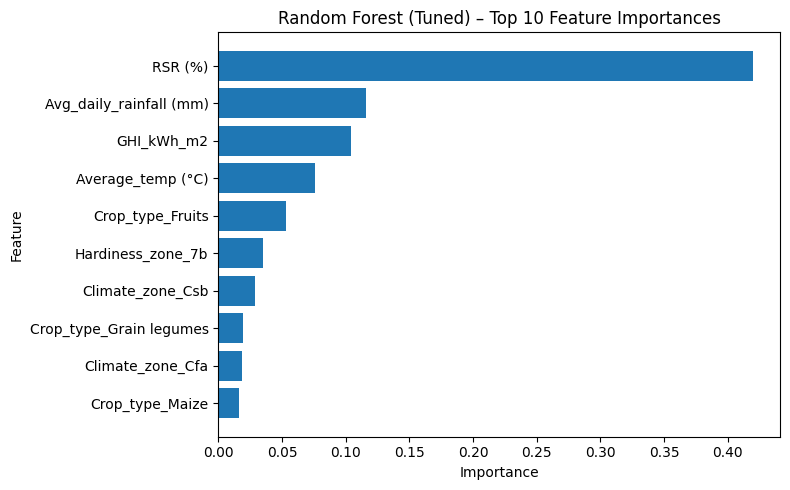

In [8]:
# ---------------------------------------------------------------------
# Plotting top 10 feature importances
# ---------------------------------------------------------------------
top_n = 10
top_imp = rf_importance_df.head(top_n).iloc[::-1]  # reverse for horizontal bar order

plt.figure(figsize=(8, 5))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest (Tuned) – Top 10 Feature Importances")
plt.tight_layout()
plt.show()


In [9]:
# Saving Plot
rf_importance_df.to_csv("rf_core_tuned_feature_importances.csv", index=False)
plt.figure(figsize=(8, 5))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest (Tuned) – Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("rf_core_tuned_top10_importances.png", dpi=300, bbox_inches="tight")
plt.close()


#### Prediction Quality Plots (Random Forest): 
We assess prediction quality for the **tuned** Random Forest via:  
1) Actual vs. Predicted scatter with a 45° reference line,  
2) Residuals vs. Predicted to check structure/heteroskedasticity,  
3) Error distribution (histogram + KDE), and  
4) QQ plot to compare residuals against a normal distribution.  
These diagnostics help verify whether remaining errors are unbiased and roughly homoscedastic.


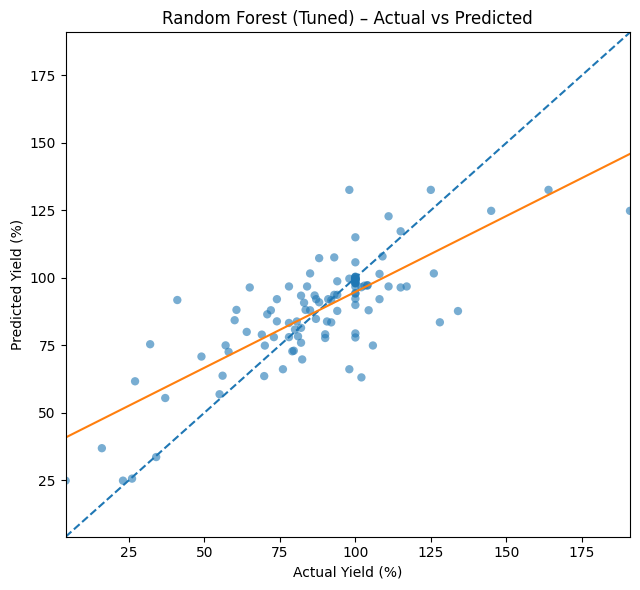

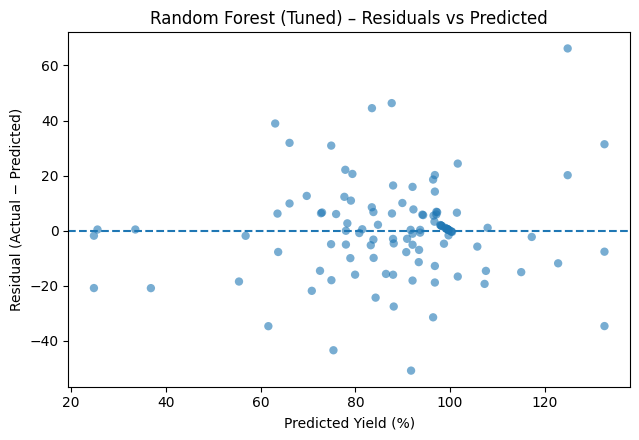

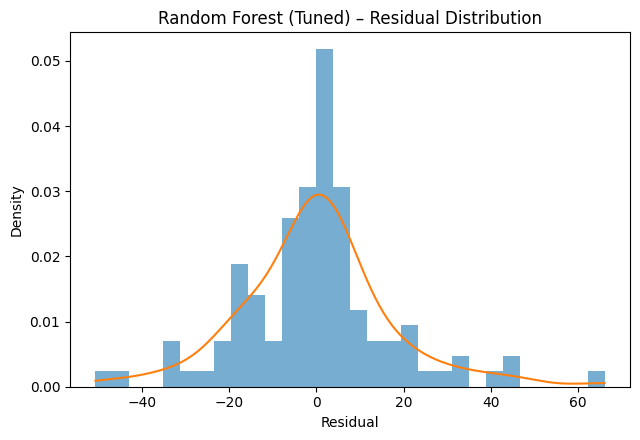

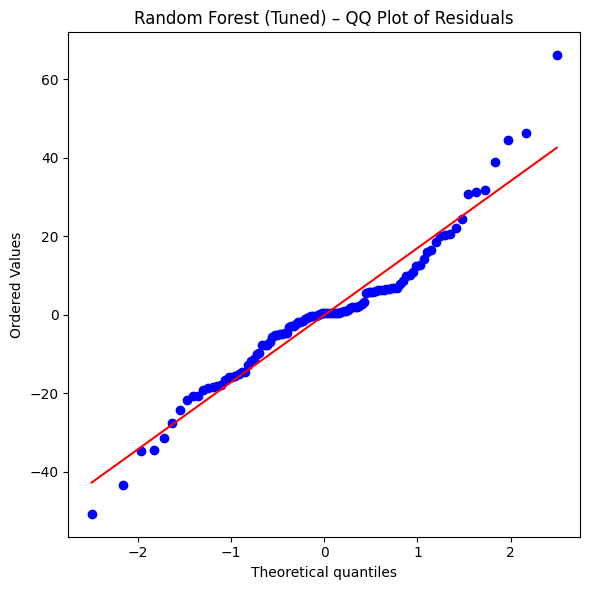

In [10]:
from scipy import stats

# ---------------------------------------------------------------------
# Preparing residuals from the tuned model
# ---------------------------------------------------------------------
y_true = y_test.values
y_pred = y_pred_tuned
residuals = y_true - y_pred

# ---------------------------------------------------------------------
# 1) Actual vs Predicted
# ---------------------------------------------------------------------
plt.figure(figsize=(6.5, 6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='none')
# 45-degree line (perfect predictions)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, linestyle='--')
# Optional least-squares fit line to visualize trend
m, b = np.polyfit(y_true, y_pred, 1)
plt.plot(lims, m*np.array(lims) + b)

plt.title("Random Forest (Tuned) – Actual vs Predicted")
plt.xlabel("Actual Yield (%)")
plt.ylabel("Predicted Yield (%)")
plt.xlim(lims); plt.ylim(lims)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2) Residuals vs Predicted
# ---------------------------------------------------------------------
plt.figure(figsize=(6.5, 4.5))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor='none')
plt.axhline(0.0, linestyle='--')
plt.title("Random Forest (Tuned) – Residuals vs Predicted")
plt.xlabel("Predicted Yield (%)")
plt.ylabel("Residual (Actual − Predicted)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3) Error distribution (histogram + KDE)
# ---------------------------------------------------------------------
plt.figure(figsize=(6.5, 4.5))
# Histogram
counts, bins, patches = plt.hist(residuals, bins=30, density=True, alpha=0.6)
kde = stats.gaussian_kde(residuals)
xs = np.linspace(residuals.min(), residuals.max(), 250)
plt.plot(xs, kde(xs))
plt.title("Random Forest (Tuned) – Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4) QQ plot (residuals vs normal)
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Random Forest (Tuned) – QQ Plot of Residuals")
plt.tight_layout()
plt.show()


In [11]:
# Saving Figures
def save_fig(path, fig_func):
    plt.figure()
    fig_func()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()

# Helper lambdas to rebuild each plot quickly
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
m, b = np.polyfit(y_true, y_pred, 1)

save_fig("rf_tuned_actual_vs_pred.png", lambda: (
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='none'),
    plt.plot(lims, lims, linestyle='--'),
    plt.plot(lims, m*np.array(lims) + b),
    plt.title("Random Forest (Tuned) – Actual vs Predicted"),
    plt.xlabel("Actual Yield (%)"),
    plt.ylabel("Predicted Yield (%)"),
    plt.xlim(lims), plt.ylim(lims)
))

save_fig("rf_tuned_residuals_vs_pred.png", lambda: (
    plt.scatter(y_pred, residuals, alpha=0.6, edgecolor='none'),
    plt.axhline(0.0, linestyle='--'),
    plt.title("Random Forest (Tuned) – Residuals vs Predicted"),
    plt.xlabel("Predicted Yield (%)"),
    plt.ylabel("Residual (Actual − Predicted)")
))

save_fig("rf_tuned_residual_hist.png", lambda: (
    plt.hist(residuals, bins=30, density=True, alpha=0.6),
    plt.plot(xs, kde(xs)),
    plt.title("Random Forest (Tuned) – Residual Distribution"),
    plt.xlabel("Residual"),
    plt.ylabel("Density")
))

save_fig("rf_tuned_residuals_qq.png", lambda: (
    stats.probplot(residuals, dist="norm", plot=plt),
    plt.title("Random Forest (Tuned) – QQ Plot of Residuals")
))


## Model Explainability – Partial Dependence (Random Forest): 
We’ll use **Partial Dependence Plots (PDPs)** to visualize the average marginal effect of key predictors on **Yield (%)**.  
We’ll:  
1) Select the **top features** from RF importance,  
2) Plot **1D PDPs** for the top 3 features, and  
3) Add a **2D PDP** for an interaction (e.g., RSR × Avg Temp).  



Selected features for 1D PDP: ['RSR (%)', 'Avg_daily_rainfall (mm)', 'GHI_kWh_m2']


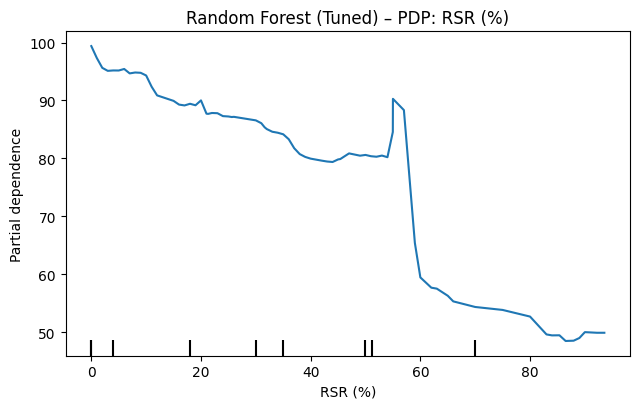

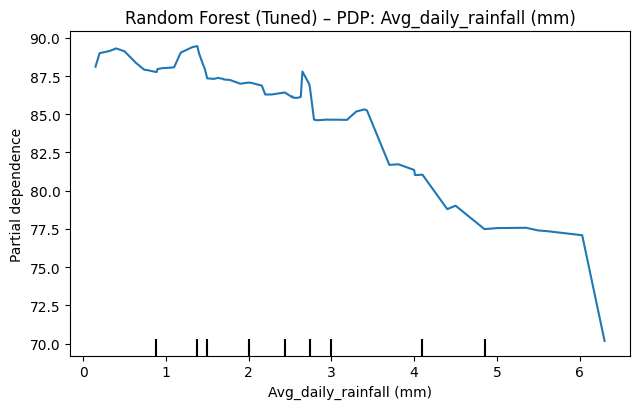

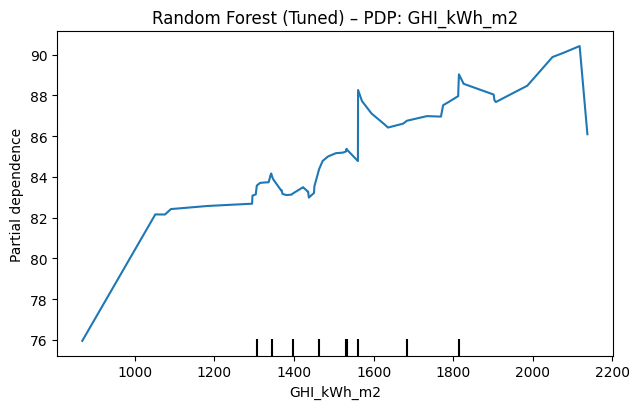

In [12]:
from sklearn.inspection import PartialDependenceDisplay

# ---------------------------------------------------------------------
# Choosing features for PDP:
#  - Using the top features from rf_importance_df (already computed above).
#  - Prefering numeric features first; if not present in top 3, falling back to next ones.
# ---------------------------------------------------------------------
numeric_core = ['RSR (%)', 'Average_temp (°C)', 'Avg_daily_rainfall (mm)', 'GHI_kWh_m2']

# Getting top features from importance table
top_features_all = rf_importance_df['feature'].tolist()

# Trying to prioritize 2 numeric + 1 best remaining (numeric or categorical dummy)
top_numeric = [f for f in top_features_all if f in numeric_core][:2]
remaining = [f for f in top_features_all if f not in top_numeric]
top3_for_pdp = (top_numeric + remaining)[:3]

print("Selected features for 1D PDP:", top3_for_pdp)

# ---------------------------------------------------------------------
# 1D PDPs for the top three features
# ---------------------------------------------------------------------
for feat in top3_for_pdp:
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    _ = PartialDependenceDisplay.from_estimator(
        rf_tuned,
        X_train,
        [feat],
        ax=ax
    )
    ax.set_title(f"Random Forest (Tuned) – PDP: {feat}")
    ax.set_ylabel("Partial dependence (Yield %)")
    plt.tight_layout()
    plt.show()


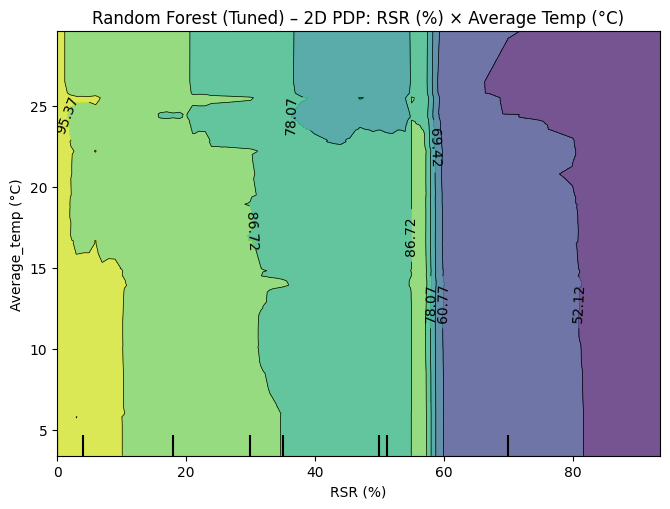

In [13]:
# ---------------------------------------------------------------------
# 2D PDP for interaction between two numeric features
#   - If both exist, RSR (%) × Average_temp (°C) is a natural pair
# ---------------------------------------------------------------------
pair = ['RSR (%)', 'Average_temp (°C)']
if all(f in X_train.columns for f in pair):
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    _ = PartialDependenceDisplay.from_estimator(
        rf_tuned,
        X_train,
        [tuple(pair)],  # 2D PDP expects a tuple for the pair
        ax=ax,
        kind="average"
    )
    ax.set_title("Random Forest (Tuned) – 2D PDP: RSR (%) × Average Temp (°C)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping 2D PDP: one or both features not found:", pair)


     GHI_kWh_m2  Baseline_predicted_yield_at_0_RSR  Yield_threshold_value  \
0   1184.100000                          99.006783              89.106104   
1   1208.961207                          99.011680              89.110512   
2   1233.822414                          99.011680              89.110512   
3   1258.683621                          99.014592              89.113132   
4   1283.544828                          99.044464              89.140018   
5   1308.406034                          99.363265              89.426939   
6   1333.267241                          99.394724              89.455251   
7   1358.128448                          99.331529              89.398376   
8   1382.989655                          99.228959              89.306063   
9   1407.850862                          99.237983              89.314184   
10  1432.712069                          99.271603              89.344443   
11  1457.573276                          99.369443              89.432499   

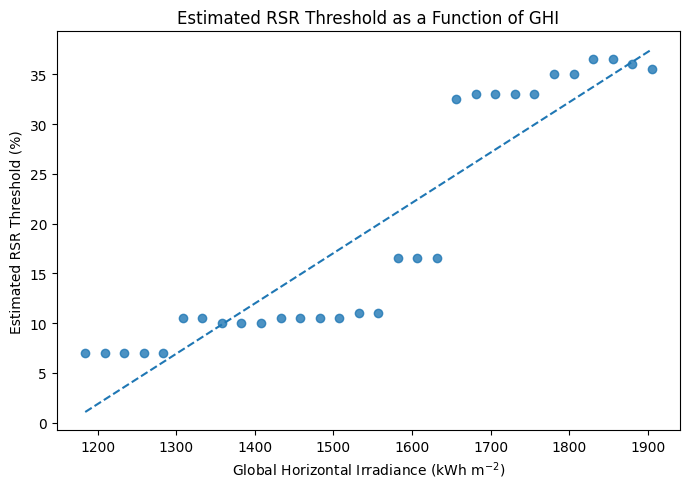

<Figure size 640x480 with 0 Axes>

In [16]:
from sklearn.linear_model import LinearRegression

# --------------------------------------------
# Fast threshold analysis: RSR threshold by GHI
# --------------------------------------------

yield_drop_fraction = 0.10  # threshold = 10% yield drop from predicted 0% RSR

rsr_grid = np.linspace(0, 90, 181)

ghi_grid = np.linspace(
    X_train["GHI_kWh_m2"].quantile(0.05),
    X_train["GHI_kWh_m2"].quantile(0.95),
    30
)

# Representative baseline row:
# numeric variables = median
# dummy variables = mode
base_row = X_train.median(numeric_only=True)

for col in X_train.columns:
    if col not in base_row.index:
        base_row[col] = X_train[col].mode().iloc[0]

base_row = base_row[X_train.columns]

rows = []
for ghi_value in ghi_grid:
    for rsr_value in rsr_grid:
        row = base_row.copy()
        row["RSR (%)"] = rsr_value
        row["GHI_kWh_m2"] = ghi_value
        rows.append(row)

grid_df = pd.DataFrame(rows)

# One batch prediction instead of thousands of separate predictions
grid_df["Predicted_yield"] = rf_tuned.predict(grid_df)

threshold_results = []

for ghi_value in ghi_grid:
    temp = grid_df[grid_df["GHI_kWh_m2"] == ghi_value].sort_values("RSR (%)")

    baseline_yield = temp.loc[temp["RSR (%)"].idxmin(), "Predicted_yield"]
    threshold_yield = baseline_yield * (1 - yield_drop_fraction)

    below = temp[temp["Predicted_yield"] <= threshold_yield]

    if len(below) > 0:
        rsr_threshold = below.iloc[0]["RSR (%)"]
    else:
        rsr_threshold = np.nan

    threshold_results.append({
        "GHI_kWh_m2": ghi_value,
        "Baseline_predicted_yield_at_0_RSR": baseline_yield,
        "Yield_threshold_value": threshold_yield,
        "RSR_threshold_percent": rsr_threshold
    })

threshold_df = pd.DataFrame(threshold_results).dropna()

# Linear relationship: RSR threshold ~ GHI
X_ghi = threshold_df[["GHI_kWh_m2"]].values
y_thresh = threshold_df["RSR_threshold_percent"].values

lin_model = LinearRegression()
lin_model.fit(X_ghi, y_thresh)

slope_per_100_kwh = lin_model.coef_[0] * 100
r2_threshold = lin_model.score(X_ghi, y_thresh)

print(threshold_df)
print(f"\nEstimated RSR threshold change per 100 kWh/m² increase in GHI: {slope_per_100_kwh:.2f} percentage points")
print(f"R² of threshold-GHI relationship: {r2_threshold:.3f}")

# Plot
ghi_line = np.linspace(threshold_df["GHI_kWh_m2"].min(),
                       threshold_df["GHI_kWh_m2"].max(), 100).reshape(-1, 1)
threshold_line = lin_model.predict(ghi_line)

plt.figure(figsize=(7, 5))
plt.scatter(threshold_df["GHI_kWh_m2"], threshold_df["RSR_threshold_percent"], alpha=0.8)
plt.plot(ghi_line, threshold_line, linestyle="--")
plt.xlabel("Global Horizontal Irradiance (kWh m$^{-2}$)")
plt.ylabel("Estimated RSR Threshold (%)")
plt.title("Estimated RSR Threshold as a Function of GHI")
plt.tight_layout()
plt.show()

threshold_df.to_csv("rf_rsr_threshold_by_ghi.csv", index=False)
plt.savefig("rf_rsr_threshold_by_ghi.png", dpi=300, bbox_inches="tight")

## HistGradientBoosting

#### **Default Model**: Training an HGB regressor on the same core feature set with default hyperparameters to set a baseline. Then evaluating with R², RMSE, MAE.

In [ ]:
# =====================================================================
# HistGradientBoosting – Default Model on Core Features
# =====================================================================
from sklearn.ensemble import HistGradientBoostingRegressor

# ---------------------------------------------------------------------
# Step 1: Fitting default HGB
# ---------------------------------------------------------------------
hgb_default = HistGradientBoostingRegressor(random_state=42)
hgb_default.fit(X_train, y_train)

# ---------------------------------------------------------------------
# Step 2: Predicting on the test set
# ---------------------------------------------------------------------
y_pred_hgb_default = hgb_default.predict(X_test)

# ---------------------------------------------------------------------
# Step 3: Evaluating performance (R², RMSE, MAE)
# ---------------------------------------------------------------------
r2_hgb_default = r2_score(y_test, y_pred_hgb_default)
rmse_hgb_default = np.sqrt(mean_squared_error(y_test, y_pred_hgb_default))
mae_hgb_default = mean_absolute_error(y_test, y_pred_hgb_default)

print("HistGradientBoosting – Core Features (Default Parameters)")
print(f"R²   : {r2_hgb_default:.4f}")
print(f"RMSE : {rmse_hgb_default:.2f}")
print(f"MAE  : {mae_hgb_default:.2f}")


HistGradientBoosting – Core Features (Default Parameters)
R²   : 0.5464
RMSE : 18.55
MAE  : 13.28


#### **Hyperparameter Tuning**: Using a randomized search over a compact but effective space for HGB. Optimizing R² with 5-fold CV. Reporting best params, CV R² (mean ± std), and held-out test metrics.

In [12]:
# =====================================================================
# HistGradientBoosting – Hyperparameter Tuning (RandomizedSearchCV)
# =====================================================================
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from scipy.stats import randint, uniform, loguniform
import time

# Reusable 5-fold CV splitter
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------------------
# Step 1: Defining parameter search space for HGB
# Notes:
# - max_depth or max_leaf_nodes controls tree size.
# - max_bins can influence accuracy when there are many unique values.
# - early_stopping=False for deterministic CV behavior.
# ---------------------------------------------------------------------
hgb_base = HistGradientBoostingRegressor(
    loss="squared_error",
    early_stopping=False,
    random_state=42
)

param_distributions_hgb = {
    "learning_rate": loguniform(1e-3, 3e-1),  # ~[0.001, 0.3]
    "max_iter": randint(200, 1200),           # boosting rounds
    "max_depth": randint(2, 20),              # tree depth
    "min_samples_leaf": randint(5, 60),       # regularization
    "l2_regularization": loguniform(1e-6, 1.0),
    "max_bins": randint(60, 255)              # histogram bins (8..255 allowed)
}

random_search_hgb = RandomizedSearchCV(
    estimator=hgb_base,
    param_distributions=param_distributions_hgb,
    n_iter=80,
    scoring="r2",
    cv=cv5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

t0 = time.time()
random_search_hgb.fit(X_train, y_train)
tuned_time_hgb = time.time() - t0

print(f"\nHGB randomized search completed in {tuned_time_hgb:.1f}s")
print("Best CV R² from search:", f"{random_search_hgb.best_score_:.4f}")
print("Best HGB hyperparameters:", random_search_hgb.best_params_)

# ---------------------------------------------------------------------
# Step 2: Evaluating tuned HGB on held-out test set
# ---------------------------------------------------------------------
hgb_tuned = random_search_hgb.best_estimator_
y_pred_hgb_tuned = hgb_tuned.predict(X_test)

r2_hgb_tuned = r2_score(y_test, y_pred_hgb_tuned)
rmse_hgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_hgb_tuned))
mae_hgb_tuned = mean_absolute_error(y_test, y_pred_hgb_tuned)

print("\nHistGradientBoosting – Core Features (Tuned Parameters)")
print(f"Test R²   : {r2_hgb_tuned:.4f}")
print(f"Test RMSE : {rmse_hgb_tuned:.2f}")
print(f"Test MAE  : {mae_hgb_tuned:.2f}")

# ---------------------------------------------------------------------
# Step 3: Cross-validated performance of tuned HGB (train folds)
# ---------------------------------------------------------------------
cv_scores_hgb = cross_val_score(hgb_tuned, X_train, y_train, scoring="r2", cv=cv5, n_jobs=-1)
print("\nCross-validated R² (HGB tuned, train folds): "
      f"{cv_scores_hgb.mean():.4f} ± {cv_scores_hgb.std():.4f}")

hgb_results = {
    "model": "HistGradientBoosting",
    "version": "tuned",
    "best_params": random_search_hgb.best_params_,
    "cv_r2_mean": float(cv_scores_hgb.mean()),
    "cv_r2_std": float(cv_scores_hgb.std()),
    "test_r2": float(r2_hgb_tuned),
    "test_rmse": float(rmse_hgb_tuned),
    "test_mae": float(mae_hgb_tuned),
}
hgb_results


Fitting 5 folds for each of 80 candidates, totalling 400 fits

HGB randomized search completed in 306.5s
Best CV R² from search: 0.5378
Best HGB hyperparameters: {'l2_regularization': 1.2468020662092016e-06, 'learning_rate': 0.0037320890954907564, 'max_bins': 151, 'max_depth': 16, 'max_iter': 1155, 'min_samples_leaf': 11}

HistGradientBoosting – Core Features (Tuned Parameters)
Test R²   : 0.5933
Test RMSE : 17.56
Test MAE  : 12.20

Cross-validated R² (HGB tuned, train folds): 0.5378 ± 0.1451


{'model': 'HistGradientBoosting',
 'version': 'tuned',
 'best_params': {'l2_regularization': 1.2468020662092016e-06,
  'learning_rate': 0.0037320890954907564,
  'max_bins': 151,
  'max_depth': 16,
  'max_iter': 1155,
  'min_samples_leaf': 11},
 'cv_r2_mean': 0.5378190702352954,
 'cv_r2_std': 0.14512772716976025,
 'test_r2': 0.593272165032552,
 'test_rmse': 17.560314236077474,
 'test_mae': 12.204059935170147}

#### Model Explainability – “Feature Importance” via Permutation: HGB doesn’t expose Gini importances. We’ll compute permutation importance on the test set and plot Top-10. 

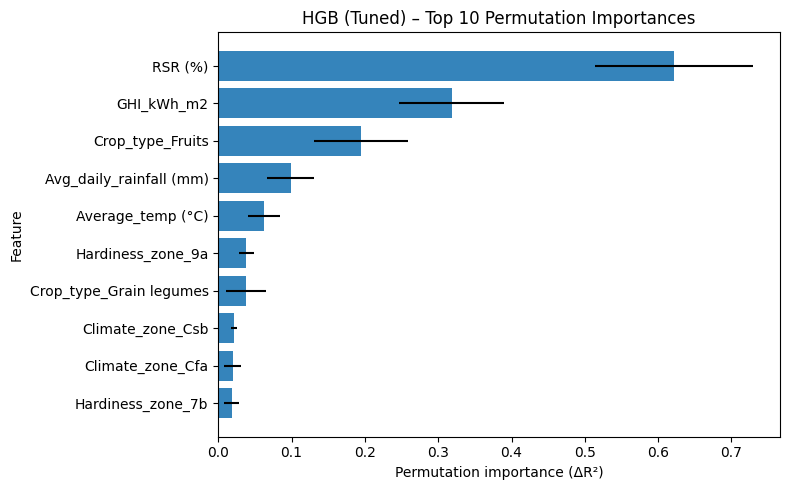

In [ ]:
# =====================================================================
# HGB – Permutation Importance (Top 10)
# =====================================================================
from sklearn.inspection import permutation_importance

feat_names = X_train.columns

# ---------------------------------------------------------------------
# Step 1: Computing permutation importance on held-out test set
# ---------------------------------------------------------------------
perm = permutation_importance(
    hgb_tuned, X_test, y_test,
    n_repeats=30,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

hgb_perm_df = (
    pd.DataFrame({
        "feature": feat_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)


hgb_perm_df.head(15)

# ---------------------------------------------------------------------
# Step 2: Plotting Top-10 permutation importances
# ---------------------------------------------------------------------
top_n = 10
top_perm = hgb_perm_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"], alpha=0.9)
plt.xlabel("Permutation importance (ΔR²)")
plt.ylabel("Feature")
plt.title("HGB (Tuned) – Top 10 Permutation Importances")
plt.tight_layout()
plt.show()

# Saving table + figure
hgb_perm_df.to_csv("hgb_core_tuned_permutation_importance.csv", index=False)
plt.figure(figsize=(8, 5))
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"], alpha=0.9)
plt.xlabel("Permutation importance (ΔR²)")
plt.ylabel("Feature")
plt.title("HGB (Tuned) – Top 10 Permutation Importances")
plt.tight_layout()
plt.savefig("hgb_core_tuned_perm_top10.png", dpi=300, bbox_inches="tight")
plt.close()


#### Prediction Diagnostics (HGB):
- Actual vs Predicted,

- Residuals vs Predicted,

- Residual Histogram + KDE,

- QQ Plot.


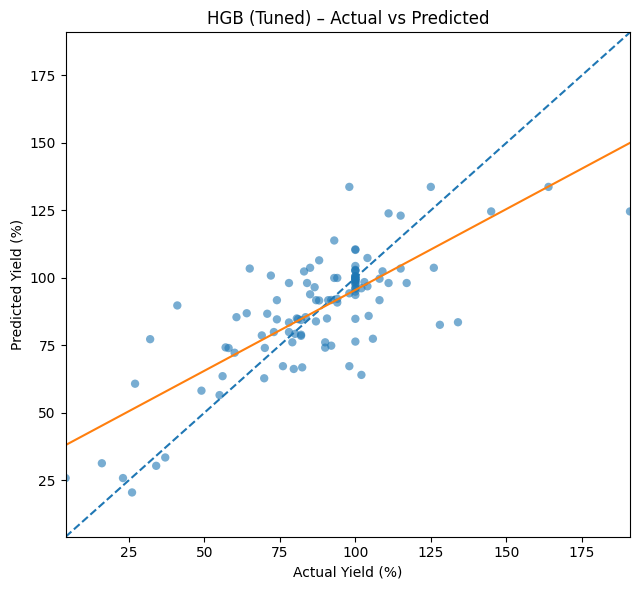

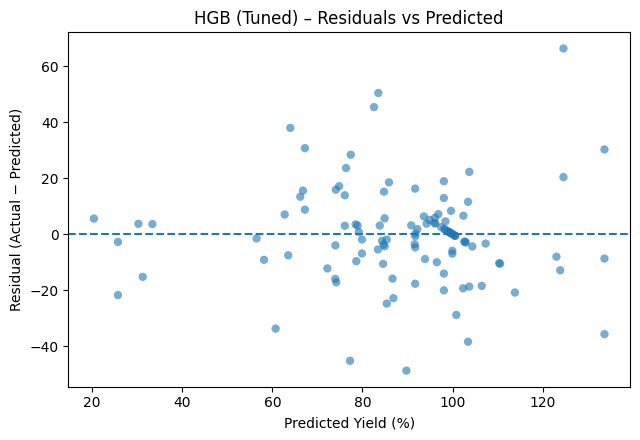

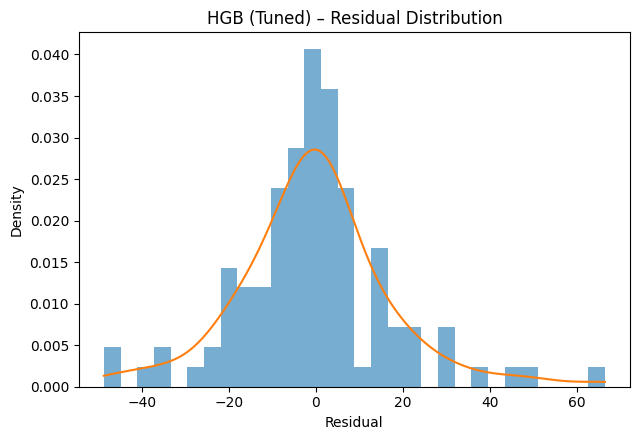

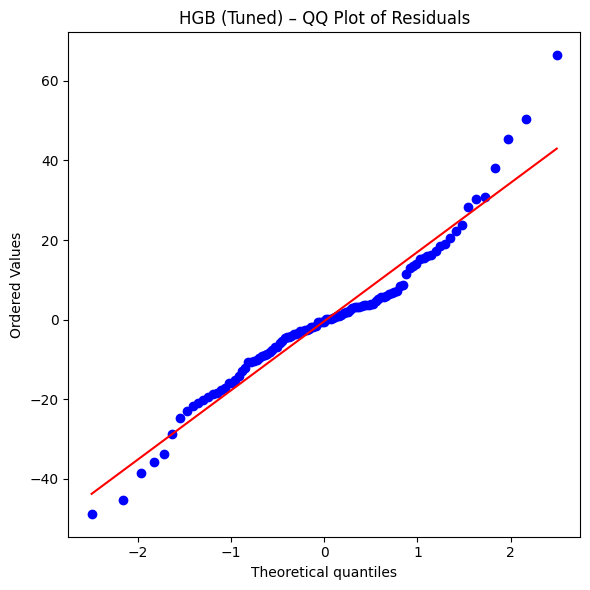

In [14]:
# =====================================================================
# HGB – Prediction Diagnostics
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Residuals
y_true_hgb = y_test.values
y_pred_hgb = y_pred_hgb_tuned
res_hgb = y_true_hgb - y_pred_hgb

# 1) Actual vs Predicted
plt.figure(figsize=(6.5, 6))
plt.scatter(y_true_hgb, y_pred_hgb, alpha=0.6, edgecolor='none')
lims = [min(y_true_hgb.min(), y_pred_hgb.min()), max(y_true_hgb.max(), y_pred_hgb.max())]
plt.plot(lims, lims, linestyle='--')
m_hgb, b_hgb = np.polyfit(y_true_hgb, y_pred_hgb, 1)
plt.plot(lims, m_hgb*np.array(lims) + b_hgb)
plt.title("HGB (Tuned) – Actual vs Predicted")
plt.xlabel("Actual Yield (%)"); plt.ylabel("Predicted Yield (%)")
plt.xlim(lims); plt.ylim(lims); plt.tight_layout(); plt.show()

# 2) Residuals vs Predicted
plt.figure(figsize=(6.5, 4.5))
plt.scatter(y_pred_hgb, res_hgb, alpha=0.6, edgecolor='none')
plt.axhline(0.0, linestyle='--')
plt.title("HGB (Tuned) – Residuals vs Predicted")
plt.xlabel("Predicted Yield (%)"); plt.ylabel("Residual (Actual − Predicted)")
plt.tight_layout(); plt.show()

# 3) Residual histogram + KDE
plt.figure(figsize=(6.5, 4.5))
counts, bins, patches = plt.hist(res_hgb, bins=30, density=True, alpha=0.6)
kde_hgb = stats.gaussian_kde(res_hgb)
xs_hgb = np.linspace(res_hgb.min(), res_hgb.max(), 250)
plt.plot(xs_hgb, kde_hgb(xs_hgb))
plt.title("HGB (Tuned) – Residual Distribution")
plt.xlabel("Residual"); plt.ylabel("Density")
plt.tight_layout(); plt.show()

# 4) QQ plot
plt.figure(figsize=(6, 6))
stats.probplot(res_hgb, dist="norm", plot=plt)
plt.title("HGB (Tuned) – QQ Plot of Residuals")
plt.tight_layout(); plt.show()

# Saving figures
def save_fig(path, fig_func):
    plt.figure()
    fig_func()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()

save_fig("hgb_tuned_actual_vs_pred.png", lambda: (
    plt.scatter(y_true_hgb, y_pred_hgb, alpha=0.6, edgecolor='none'),
    plt.plot(lims, lims, linestyle='--'),
    plt.plot(lims, m_hgb*np.array(lims) + b_hgb),
    plt.title("HGB (Tuned) – Actual vs Predicted"),
    plt.xlabel("Actual Yield (%)"),
    plt.ylabel("Predicted Yield (%)"),
    plt.xlim(lims), plt.ylim(lims)
))

save_fig("hgb_tuned_residuals_vs_pred.png", lambda: (
    plt.scatter(y_pred_hgb, res_hgb, alpha=0.6, edgecolor='none'),
    plt.axhline(0.0, linestyle='--'),
    plt.title("HGB (Tuned) – Residuals vs Predicted"),
    plt.xlabel("Predicted Yield (%)"),
    plt.ylabel("Residual (Actual − Predicted)")
))

save_fig("hgb_tuned_residual_hist.png", lambda: (
    plt.hist(res_hgb, bins=30, density=True, alpha=0.6),
    plt.plot(xs_hgb, kde_hgb(xs_hgb)),
    plt.title("HGB (Tuned) – Residual Distribution"),
    plt.xlabel("Residual"),
    plt.ylabel("Density")
))

save_fig("hgb_tuned_residuals_qq.png", lambda: (
    stats.probplot(res_hgb, dist="norm", plot=plt),
    plt.title("HGB (Tuned) – QQ Plot of Residuals")
))


#### Partial Dependence (HGB): Using PDPs to show average marginal effects of top features (by permutation importance). We’ll do three 1D PDPs + one 2D PDP for RSR (%) × Average_temp (°C) if both exist.

Selected features for 1D PDP (HGB): ['RSR (%)', 'GHI_kWh_m2', 'Crop_type_Fruits']


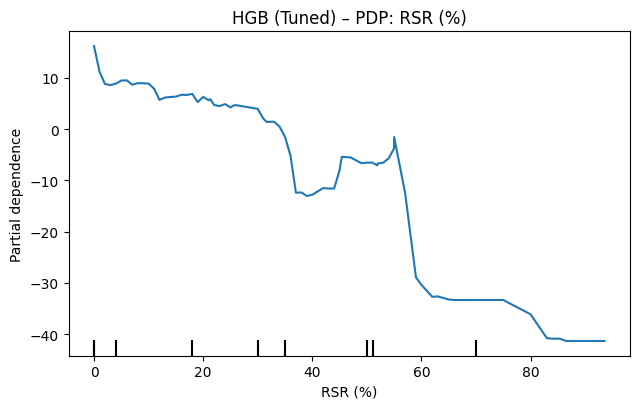

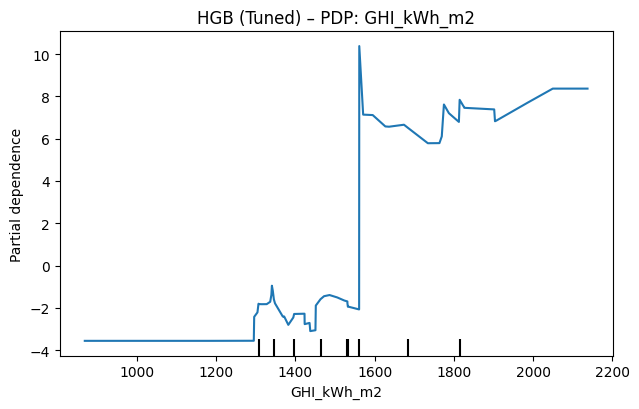

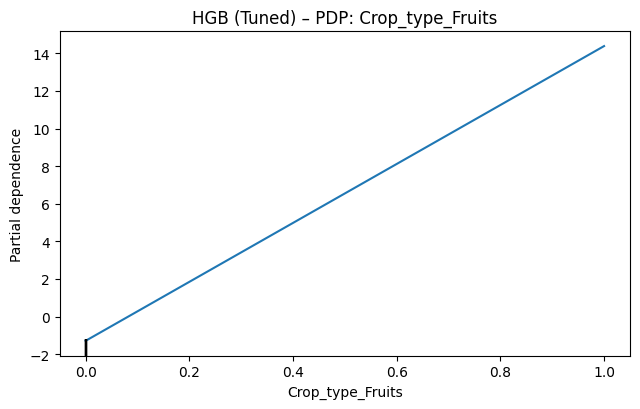

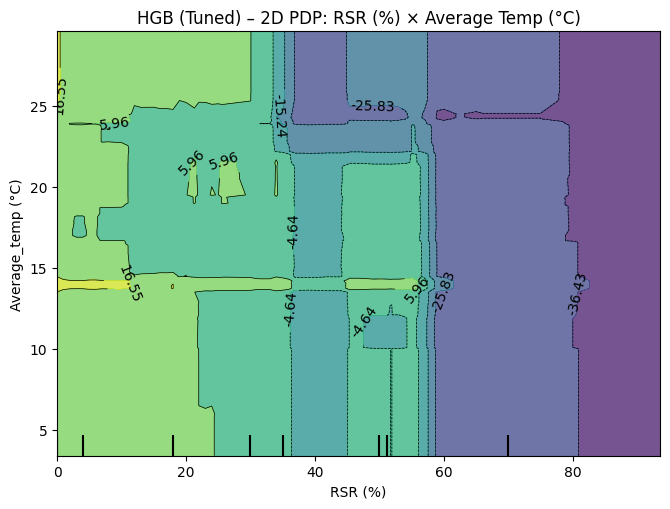

In [15]:
# =====================================================================
# HGB – Partial Dependence Plots
# =====================================================================
from sklearn.inspection import PartialDependenceDisplay

# Prefering numeric core features where possible
numeric_core = ['RSR (%)', 'Average_temp (°C)', 'Avg_daily_rainfall (mm)', 'GHI_kWh_m2']

# Picking top features from permutation importance (prioritizing 2 numeric if available)
top_features_all_hgb = hgb_perm_df['feature'].tolist()
top_numeric_hgb = [f for f in top_features_all_hgb if f in numeric_core][:2]
remaining_hgb = [f for f in top_features_all_hgb if f not in top_numeric_hgb]
top3_for_pdp_hgb = (top_numeric_hgb + remaining_hgb)[:3]
print("Selected features for 1D PDP (HGB):", top3_for_pdp_hgb)

# 1D PDPs
for feat in top3_for_pdp_hgb:
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    _ = PartialDependenceDisplay.from_estimator(
        hgb_tuned, X_train, [feat], ax=ax
    )
    ax.set_title(f"HGB (Tuned) – PDP: {feat}")
    ax.set_ylabel("Partial dependence (Yield %)")
    plt.tight_layout()
    plt.show()

# 2D PDP for interaction
pair = ['RSR (%)', 'Average_temp (°C)']
if all(f in X_train.columns for f in pair):
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    _ = PartialDependenceDisplay.from_estimator(
        hgb_tuned, X_train, [tuple(pair)], ax=ax, kind="average"
    )
    ax.set_title("HGB (Tuned) – 2D PDP: RSR (%) × Average Temp (°C)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping 2D PDP: one or both features not found:", pair)


In [ ]:
# =====================================================================
# HGB – Top-10 Feature Subset (based on permutation importance)
# =====================================================================
from sklearn.model_selection import KFold, cross_val_score

# ---------------------------------------------------------------------
# Step 1: Selecting Top-10 features from permutation importance table
#         (hgb_perm_df created earlier via permutation_importance on test set)
# ---------------------------------------------------------------------
top_k = 10
top10_feats = hgb_perm_df.head(top_k)["feature"].tolist()
print(f"Top-{top_k} features (HGB perm. importance):")
for i, f in enumerate(top10_feats, 1):
    print(f"{i:2d}. {f}")

# ---------------------------------------------------------------------
# Step 2: Building X_train/X_test using only those Top-10 features
# ---------------------------------------------------------------------
X_train_top10 = X_train[top10_feats].copy()
X_test_top10  = X_test[top10_feats].copy()

print(f"\nTop-10 subset shapes → train: {X_train_top10.shape}, test: {X_test_top10.shape}")

# 5-fold CV
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------------------
# Step 3: Baseline HGB on Top-10 (default params)
# ---------------------------------------------------------------------
hgb_top10_default = HistGradientBoostingRegressor(random_state=42, early_stopping=False)
hgb_top10_default.fit(X_train_top10, y_train)

y_pred_hgb_top10_default = hgb_top10_default.predict(X_test_top10)

r2_top10_default   = r2_score(y_test, y_pred_hgb_top10_default)
rmse_top10_default = np.sqrt(mean_squared_error(y_test, y_pred_hgb_top10_default))
mae_top10_default  = mean_absolute_error(y_test, y_pred_hgb_top10_default)

cv_top10_default = cross_val_score(
    hgb_top10_default, X_train_top10, y_train, scoring="r2", cv=cv5, n_jobs=-1
)

print("\nHGB – Top-10 Features (Default Params)")
print(f"Test R²   : {r2_top10_default:.4f}")
print(f"Test RMSE : {rmse_top10_default:.2f}")
print(f"Test MAE  : {mae_top10_default:.2f}")
print(f"CV R² (train folds): {cv_top10_default.mean():.4f} ± {cv_top10_default.std():.4f}")

# ---------------------------------------------------------------------
# Step 4: Tuned HGB on Top-10 (reuse best params from full-core search)
#         - Keeps early_stopping=False for reproducible CV behavior.
# ---------------------------------------------------------------------
best_params_core = random_search_hgb.best_params_.copy()
best_params_core.update({"early_stopping": False, "random_state": 42})

hgb_top10_tuned = HistGradientBoostingRegressor(**best_params_core)
hgb_top10_tuned.fit(X_train_top10, y_train)

y_pred_hgb_top10_tuned = hgb_top10_tuned.predict(X_test_top10)

r2_top10_tuned   = r2_score(y_test, y_pred_hgb_top10_tuned)
rmse_top10_tuned = np.sqrt(mean_squared_error(y_test, y_pred_hgb_top10_tuned))
mae_top10_tuned  = mean_absolute_error(y_test, y_pred_hgb_top10_tuned)

cv_top10_tuned = cross_val_score(
    hgb_top10_tuned, X_train_top10, y_train, scoring="r2", cv=cv5, n_jobs=-1
)

print("\nHGB – Top-10 Features (Tuned; params reused from core search)")
print(f"Test R²   : {r2_top10_tuned:.4f}")
print(f"Test RMSE : {rmse_top10_tuned:.2f}")
print(f"Test MAE  : {mae_top10_tuned:.2f}")
print(f"CV R² (train folds): {cv_top10_tuned.mean():.4f} ± {cv_top10_tuned.std():.4f}")

# ---------------------------------------------------------------------
# Step 5: Packaging results dicts for logging/reporting
# ---------------------------------------------------------------------
hgb_top10_default_results = {
    "model": "HGB",
    "subset": "top10_perm",
    "version": "default",
    "features": top10_feats,
    "cv_r2_mean": float(cv_top10_default.mean()),
    "cv_r2_std": float(cv_top10_default.std()),
    "test_r2": float(r2_top10_default),
    "test_rmse": float(rmse_top10_default),
    "test_mae": float(mae_top10_default),
}

hgb_top10_tuned_results = {
    "model": "HGB",
    "subset": "top10_perm",
    "version": "tuned_reused_params",
    "best_params_from_core": best_params_core,
    "features": top10_feats,
    "cv_r2_mean": float(cv_top10_tuned.mean()),
    "cv_r2_std": float(cv_top10_tuned.std()),
    "test_r2": float(r2_top10_tuned),
    "test_rmse": float(rmse_top10_tuned),
    "test_mae": float(mae_top10_tuned),
}

hgb_top10_default_results, hgb_top10_tuned_results


Top-10 features (HGB perm. importance):
 1. RSR (%)
 2. GHI_kWh_m2
 3. Crop_type_Fruits
 4. Avg_daily_rainfall (mm)
 5. Average_temp (°C)
 6. Hardiness_zone_9a
 7. Crop_type_Grain legumes
 8. Climate_zone_Csb
 9. Climate_zone_Cfa
10. Hardiness_zone_7b

Top-10 subset shapes → train: (432, 10), test: (109, 10)

HGB – Top-10 Features (Default Params)
Test R²   : 0.5350
Test RMSE : 18.78
Test MAE  : 13.08
CV R² (train folds): 0.5172 ± 0.1676

HGB – Top-10 Features (Tuned; params reused from core search)
Test R²   : 0.5811
Test RMSE : 17.82
Test MAE  : 12.31
CV R² (train folds): 0.5093 ± 0.1647


({'model': 'HGB',
  'subset': 'top10_perm',
  'version': 'default',
  'features': ['RSR (%)',
   'GHI_kWh_m2',
   'Crop_type_Fruits',
   'Avg_daily_rainfall (mm)',
   'Average_temp (°C)',
   'Hardiness_zone_9a',
   'Crop_type_Grain legumes',
   'Climate_zone_Csb',
   'Climate_zone_Cfa',
   'Hardiness_zone_7b'],
  'cv_r2_mean': 0.5171834625151411,
  'cv_r2_std': 0.1676186848227619,
  'test_r2': 0.5350186598850679,
  'test_rmse': 18.775784766095555,
  'test_mae': 13.082723814036123},
 {'model': 'HGB',
  'subset': 'top10_perm',
  'version': 'tuned_reused_params',
  'best_params_from_core': {'l2_regularization': 1.2468020662092016e-06,
   'learning_rate': 0.0037320890954907564,
   'max_bins': 151,
   'max_depth': 16,
   'max_iter': 1155,
   'min_samples_leaf': 11,
   'early_stopping': False,
   'random_state': 42},
  'features': ['RSR (%)',
   'GHI_kWh_m2',
   'Crop_type_Fruits',
   'Avg_daily_rainfall (mm)',
   'Average_temp (°C)',
   'Hardiness_zone_9a',
   'Crop_type_Grain legumes',
   

## XGBoost

#### Default Model

In [ ]:
# =====================================================================
# XGBoost – Default Model on Core Features
# =====================================================================
from xgboost import XGBRegressor

# ---------------------------------------------------------------------
# Step 1: Fitting default XGBRegressor
#  - n_jobs=-1 uses all cores
# ---------------------------------------------------------------------
xgb_default = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)
xgb_default.fit(X_train, y_train)

# ---------------------------------------------------------------------
# Step 2: Predicting on the test set
# ---------------------------------------------------------------------
y_pred_xgb_default = xgb_default.predict(X_test)

# ---------------------------------------------------------------------
# Step 3: Evaluating performance (R², RMSE, MAE)
# ---------------------------------------------------------------------
r2_xgb_default = r2_score(y_test, y_pred_xgb_default)
rmse_xgb_default = np.sqrt(mean_squared_error(y_test, y_pred_xgb_default))
mae_xgb_default = mean_absolute_error(y_test, y_pred_xgb_default)

print("XGBoost – Core Features (Default Parameters)")
print(f"R²   : {r2_xgb_default:.4f}")
print(f"RMSE : {rmse_xgb_default:.2f}")
print(f"MAE  : {mae_xgb_default:.2f}")


XGBoost – Core Features (Default Parameters)
R²   : 0.5876
RMSE : 17.68
MAE  : 12.37


#### Hyperparameter Tuning (RandomizedSearchCV)

In [18]:
# =====================================================================
# XGBoost – Hyperparameter Tuning (RandomizedSearchCV)
# =====================================================================
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from scipy.stats import randint, uniform
import time

cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

# Parameter space
param_distributions_xgb = {
    "n_estimators": randint(200, 1200),
    "max_depth": randint(3, 20),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.5, 0.5),       # 0.5–1.0
    "colsample_bytree": uniform(0.5, 0.5),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_lambda": uniform(0.0, 5.0),      # L2 reg
    "reg_alpha": uniform(0.0, 5.0)        # L1 reg
}

xgb_base = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions_xgb,
    n_iter=75,
    scoring="r2",
    cv=cv5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

t0 = time.time()
random_search_xgb.fit(X_train, y_train)
tuned_time_xgb = time.time() - t0

print(f"\nXGB randomized search completed in {tuned_time_xgb:.1f}s")
print("Best CV R² from search:", f"{random_search_xgb.best_score_:.4f}")
print("Best hyperparameters:", random_search_xgb.best_params_)

# ---------------------------------------------------------------------
# Step 2: Evaluating tuned model on test set
# ---------------------------------------------------------------------
xgb_tuned = random_search_xgb.best_estimator_
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("\nXGBoost – Core Features (Tuned Parameters)")
print(f"Test R²   : {r2_xgb_tuned:.4f}")
print(f"Test RMSE : {rmse_xgb_tuned:.2f}")
print(f"Test MAE  : {mae_xgb_tuned:.2f}")

# CV scores on train folds
cv_scores_xgb = cross_val_score(xgb_tuned, X_train, y_train, scoring="r2", cv=cv5, n_jobs=-1)
print(f"\nCross-validated R²: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

xgb_results = {
    "model": "XGBoost",
    "version": "tuned",
    "best_params": random_search_xgb.best_params_,
    "cv_r2_mean": float(cv_scores_xgb.mean()),
    "cv_r2_std": float(cv_scores_xgb.std()),
    "test_r2": float(r2_xgb_tuned),
    "test_rmse": float(rmse_xgb_tuned),
    "test_mae": float(mae_xgb_tuned),
}


Fitting 5 folds for each of 75 candidates, totalling 375 fits

XGB randomized search completed in 109.1s
Best CV R² from search: 0.5314
Best hyperparameters: {'colsample_bytree': 0.9367893120533886, 'gamma': 4.604362002659066, 'learning_rate': 0.028323387956459126, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 207, 'reg_alpha': 3.7412984519182917, 'reg_lambda': 0.9226050967818866, 'subsample': 0.6046746616683552}

XGBoost – Core Features (Tuned Parameters)
Test R²   : 0.5903
Test RMSE : 17.63
Test MAE  : 12.18

Cross-validated R²: 0.5314 ± 0.2029


#### Feature Importance (Gain-Based)

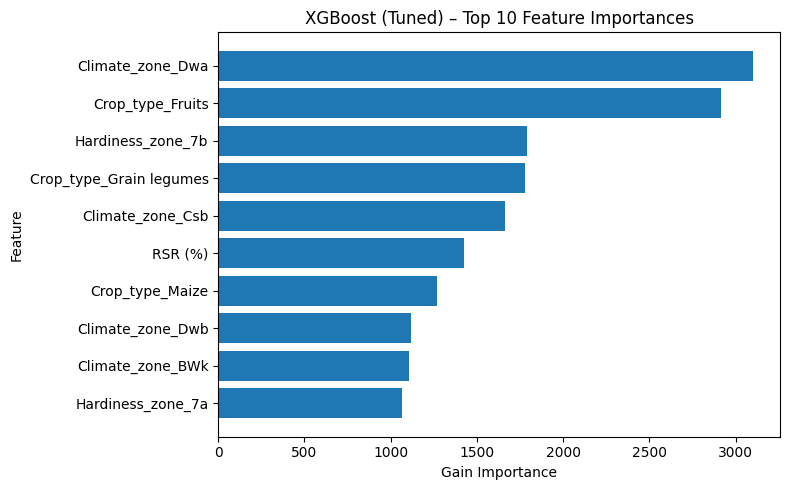

In [ ]:
# =====================================================================
# XGBoost – Feature Importance (Top-10, Gain-based)
# =====================================================================


feat_names = X_train.columns
importances_xgb = xgb_tuned.get_booster().get_score(importance_type="gain")

xgb_importance_df = (
    pd.DataFrame({"feature": list(importances_xgb.keys()),
                  "importance": list(importances_xgb.values())})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

xgb_importance_df.head(15)

# Plotting top-10
top_n = 10
top_imp_xgb = xgb_importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(top_imp_xgb["feature"], top_imp_xgb["importance"])
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("XGBoost (Tuned) – Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# Saving
xgb_importance_df.to_csv("xgb_core_tuned_feature_importances.csv", index=False)
plt.figure(figsize=(8, 5))
plt.barh(top_imp_xgb["feature"], top_imp_xgb["importance"])
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("XGBoost (Tuned) – Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("xgb_core_tuned_top10_importances.png", dpi=300, bbox_inches="tight")
plt.close()


#### Prediction Diagnostics

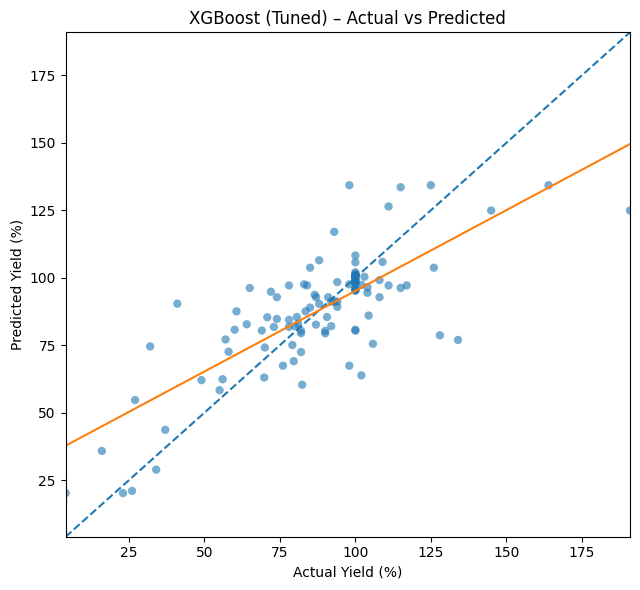

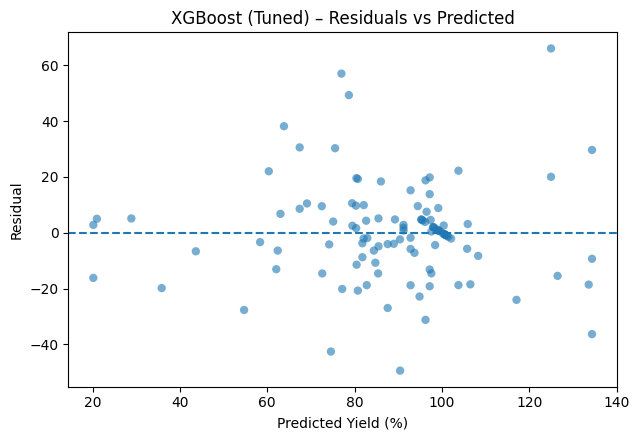

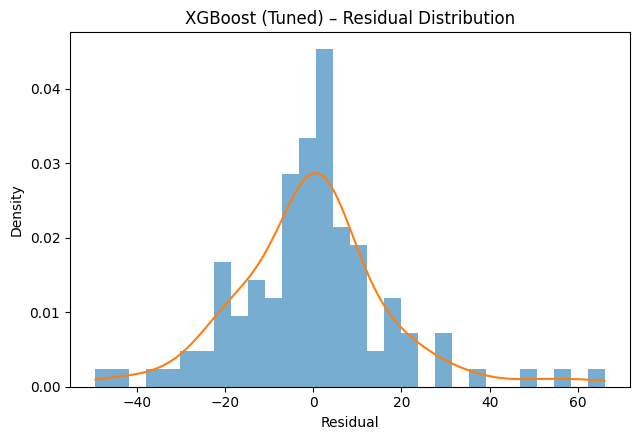

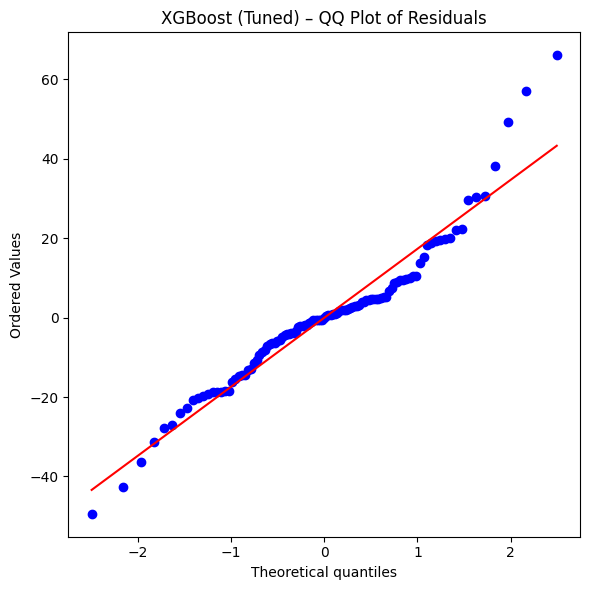

In [20]:
# =====================================================================
# XGBoost – Prediction Diagnostics
# =====================================================================
from scipy import stats

y_true_xgb = y_test.values
y_pred_xgb = y_pred_xgb_tuned
res_xgb = y_true_xgb - y_pred_xgb

# 1) Actual vs Predicted
plt.figure(figsize=(6.5, 6))
plt.scatter(y_true_xgb, y_pred_xgb, alpha=0.6, edgecolor='none')
lims = [min(y_true_xgb.min(), y_pred_xgb.min()), max(y_true_xgb.max(), y_pred_xgb.max())]
plt.plot(lims, lims, linestyle='--')
m_xgb, b_xgb = np.polyfit(y_true_xgb, y_pred_xgb, 1)
plt.plot(lims, m_xgb*np.array(lims) + b_xgb)
plt.title("XGBoost (Tuned) – Actual vs Predicted")
plt.xlabel("Actual Yield (%)"); plt.ylabel("Predicted Yield (%)")
plt.xlim(lims); plt.ylim(lims); plt.tight_layout(); plt.show()

# 2) Residuals vs Predicted
plt.figure(figsize=(6.5, 4.5))
plt.scatter(y_pred_xgb, res_xgb, alpha=0.6, edgecolor='none')
plt.axhline(0.0, linestyle='--')
plt.title("XGBoost (Tuned) – Residuals vs Predicted")
plt.xlabel("Predicted Yield (%)"); plt.ylabel("Residual")
plt.tight_layout(); plt.show()

# 3) Residual Histogram + KDE
plt.figure(figsize=(6.5, 4.5))
counts, bins, patches = plt.hist(res_xgb, bins=30, density=True, alpha=0.6)
kde_xgb = stats.gaussian_kde(res_xgb)
xs_xgb = np.linspace(res_xgb.min(), res_xgb.max(), 250)
plt.plot(xs_xgb, kde_xgb(xs_xgb))
plt.title("XGBoost (Tuned) – Residual Distribution")
plt.xlabel("Residual"); plt.ylabel("Density")
plt.tight_layout(); plt.show()

# 4) QQ Plot
plt.figure(figsize=(6, 6))
stats.probplot(res_xgb, dist="norm", plot=plt)
plt.title("XGBoost (Tuned) – QQ Plot of Residuals")
plt.tight_layout(); plt.show()


#### Partial Dependence Plots

Selected features for PDP: ['RSR (%)', 'GHI_kWh_m2', 'Climate_zone_Dwa']


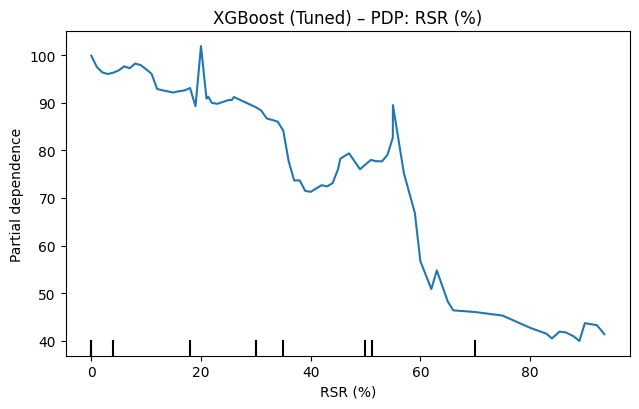

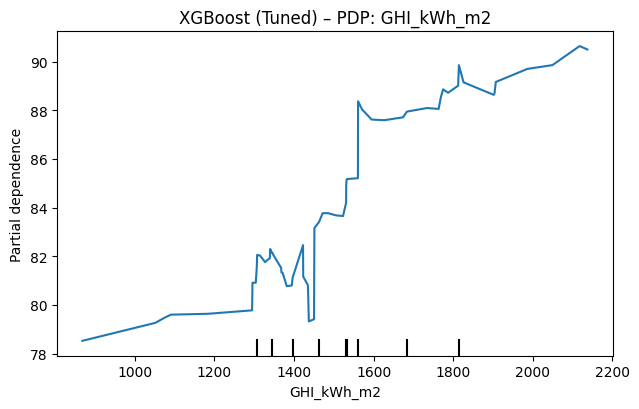

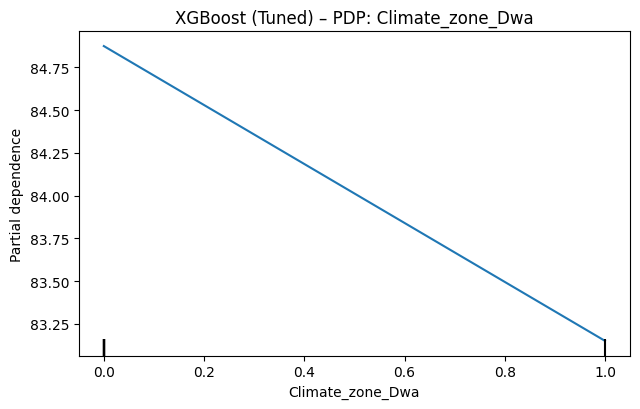

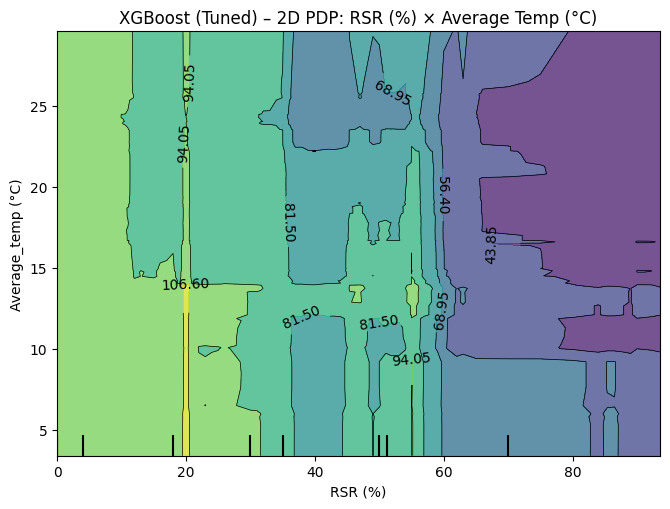

In [22]:
# =====================================================================
# XGBoost – Partial Dependence Plots
# =====================================================================
from sklearn.inspection import PartialDependenceDisplay

numeric_core = ['RSR (%)', 'Average_temp (°C)', 'Avg_daily_rainfall (mm)', 'GHI_kWh_m2']

top_features_all_xgb = xgb_importance_df['feature'].tolist()
top_numeric_xgb = [f for f in top_features_all_xgb if f in numeric_core][:2]
remaining_xgb = [f for f in top_features_all_xgb if f not in top_numeric_xgb]
top3_for_pdp_xgb = (top_numeric_xgb + remaining_xgb)[:3]
print("Selected features for PDP:", top3_for_pdp_xgb)

for feat in top3_for_pdp_xgb:
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    _ = PartialDependenceDisplay.from_estimator(
        xgb_tuned, X_train, [feat], ax=ax
    )
    ax.set_title(f"XGBoost (Tuned) – PDP: {feat}")
    ax.set_ylabel("Partial dependence (Yield %)")
    plt.tight_layout()
    plt.show()

pair = ['RSR (%)', 'Average_temp (°C)']
if all(f in X_train.columns for f in pair):
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    _ = PartialDependenceDisplay.from_estimator(
        xgb_tuned, X_train, [tuple(pair)], ax=ax, kind="average"
    )
    ax.set_title("XGBoost (Tuned) – 2D PDP: RSR (%) × Average Temp (°C)")
    plt.tight_layout()
    plt.show()


#### Top-10 Feature Subset (from XGBoost gain importance)

In [23]:
# =====================================================================
# XGBoost – Top-10 Feature Subset
# =====================================================================
top_k = 10
top10_feats_xgb = xgb_importance_df.head(top_k)["feature"].tolist()
X_train_top10_xgb = X_train[top10_feats_xgb]
X_test_top10_xgb  = X_test[top10_feats_xgb]

print(f"Top-{top_k} features: {top10_feats_xgb}")

# Default model
xgb_top10_default = XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist")
xgb_top10_default.fit(X_train_top10_xgb, y_train)
y_pred_xgb_top10_default = xgb_top10_default.predict(X_test_top10_xgb)

r2_top10_default_xgb   = r2_score(y_test, y_pred_xgb_top10_default)
rmse_top10_default_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_top10_default))
mae_top10_default_xgb  = mean_absolute_error(y_test, y_pred_xgb_top10_default)

cv_top10_default_xgb = cross_val_score(
    xgb_top10_default, X_train_top10_xgb, y_train, scoring="r2", cv=cv5, n_jobs=-1
)

print("\nXGB – Top-10 Features (Default)")
print(f"Test R²   : {r2_top10_default_xgb:.4f}")
print(f"Test RMSE : {rmse_top10_default_xgb:.2f}")
print(f"Test MAE  : {mae_top10_default_xgb:.2f}")
print(f"CV R²     : {cv_top10_default_xgb.mean():.4f} ± {cv_top10_default_xgb.std():.4f}")

# Tuned model (reusing best params from full-core search)
best_params_xgb_core = random_search_xgb.best_params_.copy()
best_params_xgb_core.update({"random_state": 42, "n_jobs": -1, "tree_method": "hist"})

xgb_top10_tuned = XGBRegressor(**best_params_xgb_core)
xgb_top10_tuned.fit(X_train_top10_xgb, y_train)
y_pred_xgb_top10_tuned = xgb_top10_tuned.predict(X_test_top10_xgb)

r2_top10_tuned_xgb   = r2_score(y_test, y_pred_xgb_top10_tuned)
rmse_top10_tuned_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_top10_tuned))
mae_top10_tuned_xgb  = mean_absolute_error(y_test, y_pred_xgb_top10_tuned)

cv_top10_tuned_xgb = cross_val_score(
    xgb_top10_tuned, X_train_top10_xgb, y_train, scoring="r2", cv=cv5, n_jobs=-1
)

print("\nXGB – Top-10 Features (Tuned)")
print(f"Test R²   : {r2_top10_tuned_xgb:.4f}")
print(f"Test RMSE : {rmse_top10_tuned_xgb:.2f}")
print(f"Test MAE  : {mae_top10_tuned_xgb:.2f}")
print(f"CV R²     : {cv_top10_tuned_xgb.mean():.4f} ± {cv_top10_tuned_xgb.std():.4f}")


Top-10 features: ['Climate_zone_Dwa', 'Crop_type_Fruits', 'Hardiness_zone_7b', 'Crop_type_Grain legumes', 'Climate_zone_Csb', 'RSR (%)', 'Crop_type_Maize', 'Climate_zone_Dwb', 'Climate_zone_BWk', 'Hardiness_zone_7a']

XGB – Top-10 Features (Default)
Test R²   : 0.2861
Test RMSE : 23.26
Test MAE  : 15.39
CV R²     : 0.3660 ± 0.3711

XGB – Top-10 Features (Tuned)
Test R²   : 0.4350
Test RMSE : 20.70
Test MAE  : 13.63
CV R²     : 0.5160 ± 0.1921


#### Model Comparison

=== Model Comparison Table ===


,model,version,subset,cv_r2_mean,cv_r2_std,test_r2,test_rmse,test_mae
0,RandomForest,tuned,core,0.529821,0.164103,0.604400,17.318431,11.854409
1,HistGradientBoosting,tuned,core,0.537819,0.145128,0.593272,17.560314,12.204060
2,XGBoost,tuned,core,0.531406,0.202930,0.590257,17.625282,12.181300
3,XGBoost,top10_tuned,top10_gain,0.515979,0.192062,0.434978,20.697270,13.632309
4,XGBoost,top10_default,top10_gain,0.366008,0.371112,0.286090,23.264954,15.388193
5,HGB,tuned_reused_params,top10_perm,0.509254,0.164712,0.581139,17.820311,12.313060
6,HGB,default,top10_perm,0.517183,0.167619,0.535019,18.775785,13.082724



Best model by Test R²:
{'model': 'RandomForest', 'version': 'tuned', 'subset': 'core', 'cv_r2_mean': 0.5298210013597404, 'cv_r2_std': 0.16410270054480244, 'test_r2': 0.6043998768468644, 'test_rmse': 17.31843104589654, 'test_mae': 11.854408703584843}


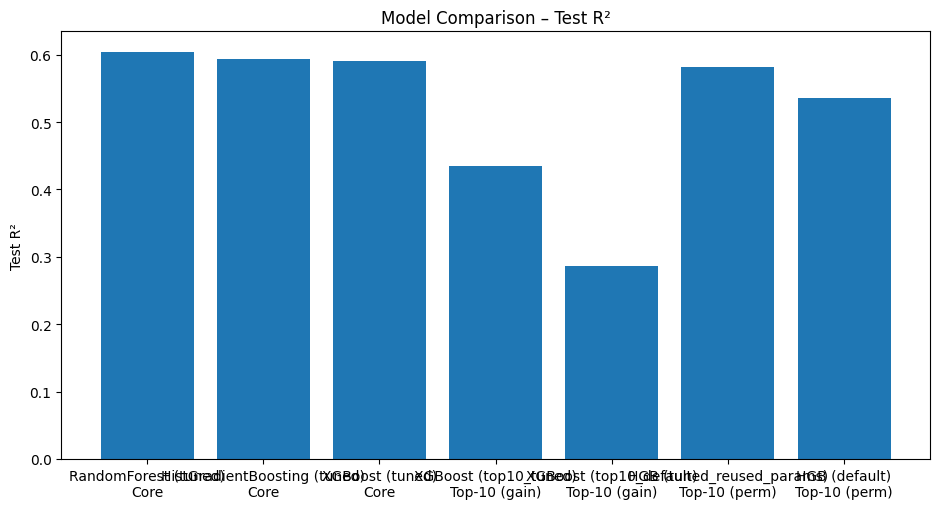

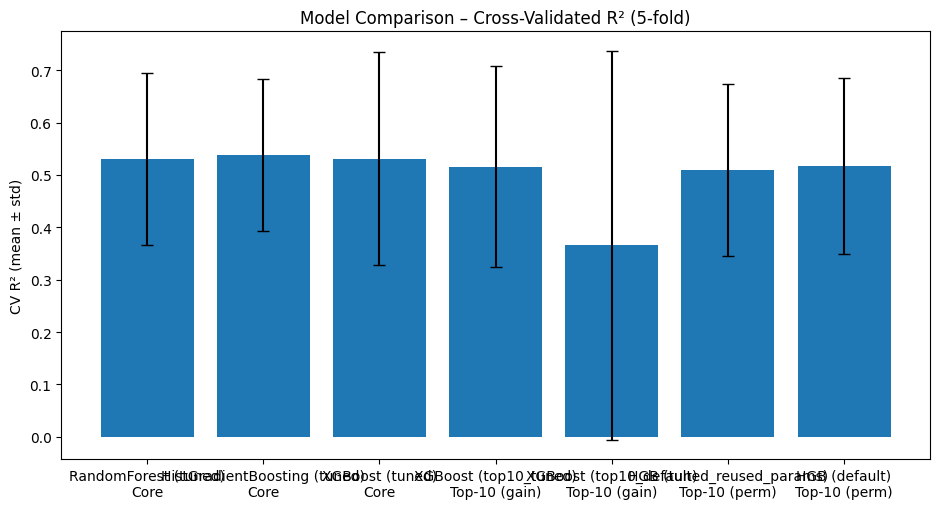

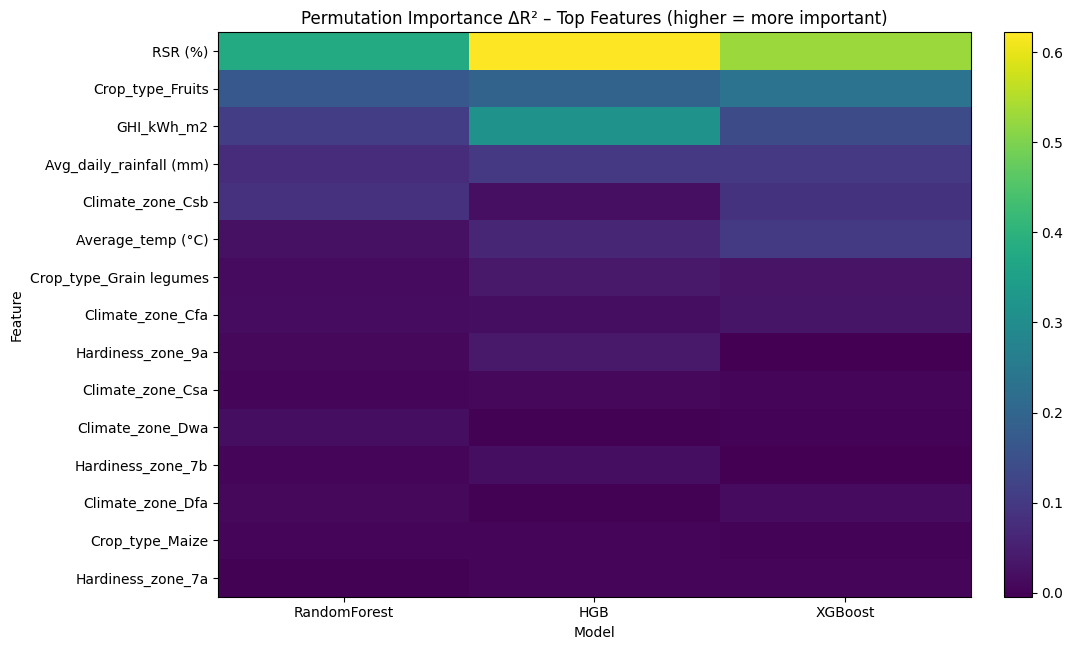


Top 2 runs for overlay: [{'model': 'RandomForest', 'version': 'tuned', 'subset': 'core', 'test_r2': 0.6043998768468644}, {'model': 'HistGradientBoosting', 'version': 'tuned', 'subset': 'core', 'test_r2': 0.593272165032552}]


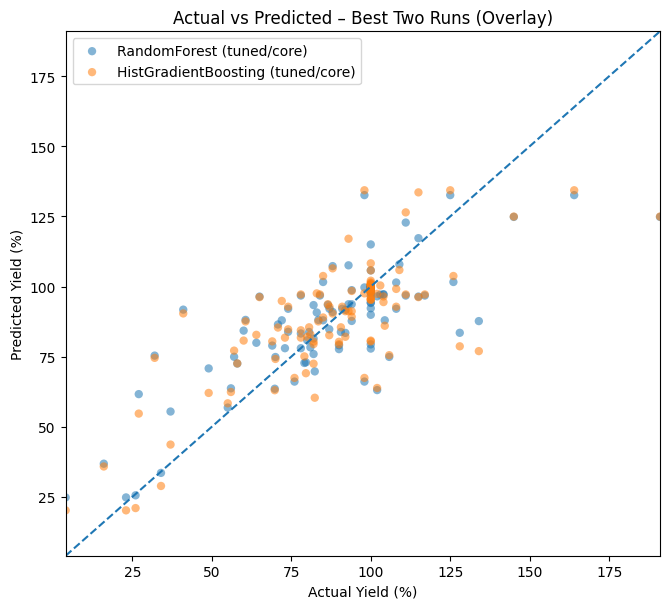

In [ ]:
# =====================================================================
# Model Comparison – Results Table + Plots + Cross-Model Importances
# =====================================================================
from sklearn.inspection import permutation_importance

# ---------------------------------------------------------------------
# Step 1: Consolidating results into a single DataFrame
# ---------------------------------------------------------------------
def _safe_row(d, fallback_model_name):
    # Making robust even if some keys are missing
    return {
        "model": d.get("model", fallback_model_name),
        "version": d.get("version", "tuned"),
        "subset": d.get("subset", "core"),
        "cv_r2_mean": d.get("cv_r2_mean", np.nan),
        "cv_r2_std": d.get("cv_r2_std", np.nan),
        "test_r2": d.get("test_r2", np.nan),
        "test_rmse": d.get("test_rmse", np.nan),
        "test_mae": d.get("test_mae", np.nan),
    }

rows = []
try: rows.append(_safe_row(rf_results, "RandomForest"))
except NameError: pass
try: rows.append(_safe_row(hgb_results, "HGB"))
except NameError: pass
try: rows.append(_safe_row(xgb_results, "XGBoost"))
except NameError: pass


try: rows.append(_safe_row(hgb_top10_default_results, "HGB"))
except NameError: pass
try: rows.append(_safe_row(hgb_top10_tuned_results, "HGB"))
except NameError: pass
try:
    rows.append({
        "model": "XGBoost",
        "version": "top10_default",
        "subset": "top10_gain",
        "cv_r2_mean": float(cv_top10_default_xgb.mean()),
        "cv_r2_std": float(cv_top10_default_xgb.std()),
        "test_r2": float(r2_top10_default_xgb),
        "test_rmse": float(rmse_top10_default_xgb),
        "test_mae": float(mae_top10_default_xgb),
    })
    rows.append({
        "model": "XGBoost",
        "version": "top10_tuned",
        "subset": "top10_gain",
        "cv_r2_mean": float(cv_top10_tuned_xgb.mean()),
        "cv_r2_std": float(cv_top10_tuned_xgb.std()),
        "test_r2": float(r2_top10_tuned_xgb),
        "test_rmse": float(rmse_top10_tuned_xgb),
        "test_mae": float(mae_top10_tuned_xgb),
    })
except NameError:
    pass

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(["subset", "test_r2"], ascending=[True, False]).reset_index(drop=True)

print("=== Model Comparison Table ===")
display(results_df)
results_df.to_csv("model_comparison_results.csv", index=False)

# Identifying overall best by test R²
if not results_df["test_r2"].isna().all():
    best_idx = results_df["test_r2"].idxmax()
    best_row = results_df.loc[best_idx]
    print("\nBest model by Test R²:")
    print(best_row.to_dict())

# ---------------------------------------------------------------------
# Step 2: Bar charts – Test R² and CV R² (with error bars)
# ---------------------------------------------------------------------
def _bar_plot_metric(df, metric_col, err_col=None, title="", fname=None):
    plt.figure(figsize=(8.5, 4.8))
    labels = df.apply(lambda r: f"{r['model']} ({r['version']})\n{subset_label(r['subset'])}", axis=1)

    # helper to shorten subset label
def subset_label(s):
    return {"core": "Core", "top10_perm": "Top-10 (perm)", "top10_gain": "Top-10 (gain)"}.get(s, s)

# Rebuilding labels with helper in scope
labels = results_df.apply(lambda r: f"{r['model']} ({r['version']})\n{subset_label(r['subset'])}", axis=1)

# --- Test R²
plt.figure(figsize=(9.5, 5.2))
plt.bar(labels, results_df["test_r2"].values)
plt.ylabel("Test R²")
plt.title("Model Comparison – Test R²")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.savefig("cmp_test_r2_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# --- CV R² (mean ± std) for train folds
plt.figure(figsize=(9.5, 5.2))
means = results_df["cv_r2_mean"].values
errs = results_df["cv_r2_std"].values
plt.bar(labels, means, yerr=errs, capsize=4)
plt.ylabel("CV R² (mean ± std)")
plt.title("Model Comparison – Cross-Validated R² (5-fold)")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.savefig("cmp_cv_r2_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------
# Step 3: Cross-model Feature Importance via Permutation (consistent metric)
#  - Computing permutation importance delta R² for each tuned model on X_test
#  - Building a wide table (features × models) and plotting a heatmap
# ---------------------------------------------------------------------
models = []
if "rf_tuned" in globals():  models.append(("RandomForest", rf_tuned))
if "hgb_tuned" in globals(): models.append(("HGB", hgb_tuned))
if "xgb_tuned" in globals(): models.append(("XGBoost", xgb_tuned))

if models:
    perm_tables = []
    for name, est in models:
        perm = permutation_importance(
            est, X_test, y_test,
            n_repeats=30, scoring="r2",
            random_state=42, n_jobs=-1
        )
        tmp = (pd.DataFrame({
                "feature": X_test.columns,
                f"{name}_perm_mean": perm.importances_mean,
                f"{name}_perm_std": perm.importances_std
             })
             .sort_values(f"{name}_perm_mean", ascending=False)
             .reset_index(drop=True))
        perm_tables.append(tmp)

    # Merging on feature
    feat_imp = perm_tables[0]
    for t in perm_tables[1:]:
        feat_imp = feat_imp.merge(t, on="feature", how="outer")

    # Filling missing with 0 (feature not used/has no effect for that model)
    feat_imp = feat_imp.fillna(0.0)

    # Ranking by average perm importance across available models
    model_mean_cols = [c for c in feat_imp.columns if c.endswith("_perm_mean")]
    feat_imp["avg_perm"] = feat_imp[model_mean_cols].mean(axis=1)
    feat_imp = feat_imp.sort_values("avg_perm", ascending=False).reset_index(drop=True)

    # Keeping Top-N for visualization
    top_n = 15
    feat_imp_top = feat_imp.head(top_n).copy()

    # Heatmap data matrix (features × models) for means only
    heat = feat_imp_top.set_index("feature")[model_mean_cols]

    # Saving tables
    feat_imp.to_csv("permutation_importance_all_models.csv", index=False)
    feat_imp_top.to_csv("permutation_importance_all_models_top15.csv", index=False)

    # --- Heatmap (matplotlib only; no seaborn)
    plt.figure(figsize=(10.8, 6.6))
    data = heat.values
    im = plt.imshow(data, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.yticks(ticks=np.arange(heat.shape[0]), labels=heat.index)
    plt.xticks(ticks=np.arange(heat.shape[1]), labels=[c.replace("_perm_mean","") for c in model_mean_cols], rotation=0)
    plt.title("Permutation Importance ΔR² – Top Features (higher = more important)")
    plt.xlabel("Model")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("cmp_perm_importance_heatmap_top15.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("No tuned models found to compute permutation importances.")

# ---------------------------------------------------------------------
# Side-by-side Actual vs Predicted overlay for best 2
#  - Quick visual check which model tracks ground truth tighter
# ---------------------------------------------------------------------
try:
    # Picking top 2 by test R² (core subset preferred; if ties, overall)
    pref = results_df.copy()
    # slight preference for 'core' subset in tie-breakers
    pref["subset_priority"] = pref["subset"].apply(lambda s: 0 if s=="core" else 1)
    top2_idx = pref.sort_values(["test_r2","subset_priority"], ascending=[False, True]).head(2).index
    top2 = results_df.loc[top2_idx]
    print("\nTop 2 runs for overlay:", top2[["model","version","subset","test_r2"]].to_dict(orient="records"))

    # Mapping to actual predictors
    overlay = []
    for _, row in top2.iterrows():
        if row["model"] == "RandomForest":
            est = rf_tuned
        elif row["model"] == "HGB":
            est = hgb_tuned
        else:
            est = xgb_tuned

        # Selecting feature subset based on row["subset"]
        if row["subset"] == "core":
            X_use = X_test
        elif row["subset"] == "top10_perm":
            X_use = X_test[hgb_top10_tuned_results["features"]] if "hgb_top10_tuned_results" in globals() else X_test
        elif row["subset"] == "top10_gain":
            X_use = X_test[top10_feats_xgb] if "top10_feats_xgb" in globals() else X_test
        else:
            X_use = X_test

        y_hat = est.predict(X_use)
        overlay.append((f"{row['model']} ({row['version']}/{row['subset']})", y_hat))

    # Plotting overlay scatter vs actual
    plt.figure(figsize=(6.8, 6.2))
    plt.scatter(y_test, overlay[0][1], alpha=0.55, label=overlay[0][0], edgecolor="none")
    if len(overlay) > 1:
        plt.scatter(y_test, overlay[1][1], alpha=0.55, label=overlay[1][0], edgecolor="none")
    lims = [min(y_test.min(), *(p.min() for _, p in overlay)),
            max(y_test.max(), *(p.max() for _, p in overlay))]
    plt.plot(lims, lims, linestyle="--")
    plt.xlabel("Actual Yield (%)"); plt.ylabel("Predicted Yield (%)")
    plt.title("Actual vs Predicted – Best Two Runs (Overlay)")
    plt.legend()
    plt.xlim(lims); plt.ylim(lims)
    plt.tight_layout()
    plt.savefig("cmp_actual_vs_pred_overlay_top2.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("Overlay plot skipped due to:", e)


In [ ]:
# =====================================================================
# Model Comparison – Ranking Table + Significance Tests
# =====================================================================

from scipy.stats import ttest_rel


df_rank = results_df.copy()

# Defining metrics to rank
metrics_to_rank = ["test_r2", "cv_r2_mean", "test_rmse", "test_mae"]

# ---------------------------------------------------------------------
# Step 1: Ranking models for each metric
# Notes:
# - Higher R² is better → rank in descending order
# - Lower RMSE/MAE is better → rank in ascending order
# ---------------------------------------------------------------------
for metric in metrics_to_rank:
    if metric in ["test_r2", "cv_r2_mean"]:
        df_rank[f"{metric}_rank"] = df_rank[metric].rank(ascending=False, method="min")
    else:  # RMSE, MAE
        df_rank[f"{metric}_rank"] = df_rank[metric].rank(ascending=True, method="min")

# ---------------------------------------------------------------------
# Step 2: Computing average rank
# ---------------------------------------------------------------------
rank_cols = [c for c in df_rank.columns if c.endswith("_rank")]
df_rank["avg_rank"] = df_rank[rank_cols].mean(axis=1)

# Sorting by average rank
df_rank_sorted = df_rank.sort_values("avg_rank").reset_index(drop=True)

print("=== Ranking Table (Lower avg_rank is better) ===")
display(df_rank_sorted[["model", "version", "subset", "avg_rank"] + rank_cols])

# Saving ranking table
df_rank_sorted.to_csv("model_comparison_ranking_table.csv", index=False)

# ---------------------------------------------------------------------
# Step 3: Paired t-tests on CV R² for top models
# ---------------------------------------------------------------------
# Extracting top N by avg_rank
top_n = 3
top_models = df_rank_sorted.head(top_n)

# We'll store CV scores in a dict for the tuned/core models
model_cv_scores = {}
for _, row in top_models.iterrows():
    mname = f"{row['model']} ({row['version']}/{row['subset']})"
    
    # Selecting correct estimator & feature set
    if row["model"] == "RandomForest":
        est = rf_tuned
    elif row["model"] == "HGB":
        est = hgb_tuned
    elif row["model"] == "XGBoost":
        est = xgb_tuned
    else:
        continue
    
    # Selecting subset of features
    if row["subset"] == "core":
        X_use = X_train
    elif row["subset"] == "top10_perm" and "hgb_top10_tuned_results" in globals():
        X_use = X_train[hgb_top10_tuned_results["features"]]
    elif row["subset"] == "top10_gain" and "top10_feats_xgb" in globals():
        X_use = X_train[top10_feats_xgb]
    else:
        X_use = X_train
    
    # Computing CV scores
    scores = cross_val_score(est, X_use, y_train, scoring="r2", cv=cv5, n_jobs=-1)
    model_cv_scores[mname] = scores

# ---------------------------------------------------------------------
# Step 4: Running paired t-tests between each pair of top models
# ---------------------------------------------------------------------
model_names = list(model_cv_scores.keys())
pval_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for i in range(len(model_names)):
    for j in range(len(model_names)):
        if i == j:
            pval_matrix.iloc[i, j] = np.nan
        else:
            # Paired t-test
            t_stat, p_val = ttest_rel(model_cv_scores[model_names[i]], model_cv_scores[model_names[j]])
            pval_matrix.iloc[i, j] = p_val

print("\n=== Paired t-test p-values (CV R²) for Top Models ===")
display(pval_matrix)

# Saving p-value matrix
pval_matrix.to_csv("model_comparison_ttest_pvalues.csv")


=== Ranking Table (Lower avg_rank is better) ===


,model,version,subset,avg_rank,test_r2_rank,cv_r2_mean_rank,test_rmse_rank,test_mae_rank
0,RandomForest,tuned,core,1.50,1.0,3.0,1.0,1.0
1,HistGradientBoosting,tuned,core,2.00,2.0,1.0,2.0,3.0
2,XGBoost,tuned,core,2.50,3.0,2.0,3.0,2.0
3,HGB,tuned_reused_params,top10_perm,4.50,4.0,6.0,4.0,4.0
4,HGB,default,top10_perm,4.75,5.0,4.0,5.0,5.0
5,XGBoost,top10_tuned,top10_gain,5.75,6.0,5.0,6.0,6.0
6,XGBoost,top10_default,top10_gain,7.00,7.0,7.0,7.0,7.0



=== Paired t-test p-values (CV R²) for Top Models ===


,RandomForest (tuned/core),XGBoost (tuned/core)
RandomForest (tuned/core),NaN,0.97833
XGBoost (tuned/core),0.97833,NaN
